In [2]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import powerlaw

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['figure.dpi'] = 150
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['axes.titlepad'] = 10
plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs

In [2]:
for f in os.listdir('/home/lpsha/s154446/fractality/data/city_degrees/'):

    path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f+'/'    
    cities = os.listdir(path)
    print(f"{f}: {len(cities)}")

t5_a5: 97
t5_a10: 97
t5_a20: 97
t5_a30: 97
t5_a40: 97
t10_a5: 97
t10_a10: 97
t10_a20: 97
t10_a30: 97
t10_a40: 97
t50_a5: 97
t50_a10: 97
t50_a20: 97
t50_a30: 97
t50_a40: 97
t100_a5: 97
t100_a10: 97
t100_a20: 97
t100_a30: 97
t100_a40: 97
t5_a5_no_simplify: 97
t5_a10_no_simplify: 97
t5_a20_no_simplify: 97
t5_a30_no_simplify: 97
t5_a40_no_simplify: 97
t10_a5_no_simplify: 97
t10_a10_no_simplify: 97
t10_a20_no_simplify: 97
t10_a30_no_simplify: 97
t10_a40_no_simplify: 97
t50_a5_no_simplify: 97
t50_a10_no_simplify: 97
t50_a20_no_simplify: 97
t50_a30_no_simplify: 97
t50_a40_no_simplify: 97
t100_a5_no_simplify: 97
t100_a10_no_simplify: 97
t100_a20_no_simplify: 97
t100_a30_no_simplify: 97
t100_a40_no_simplify: 97


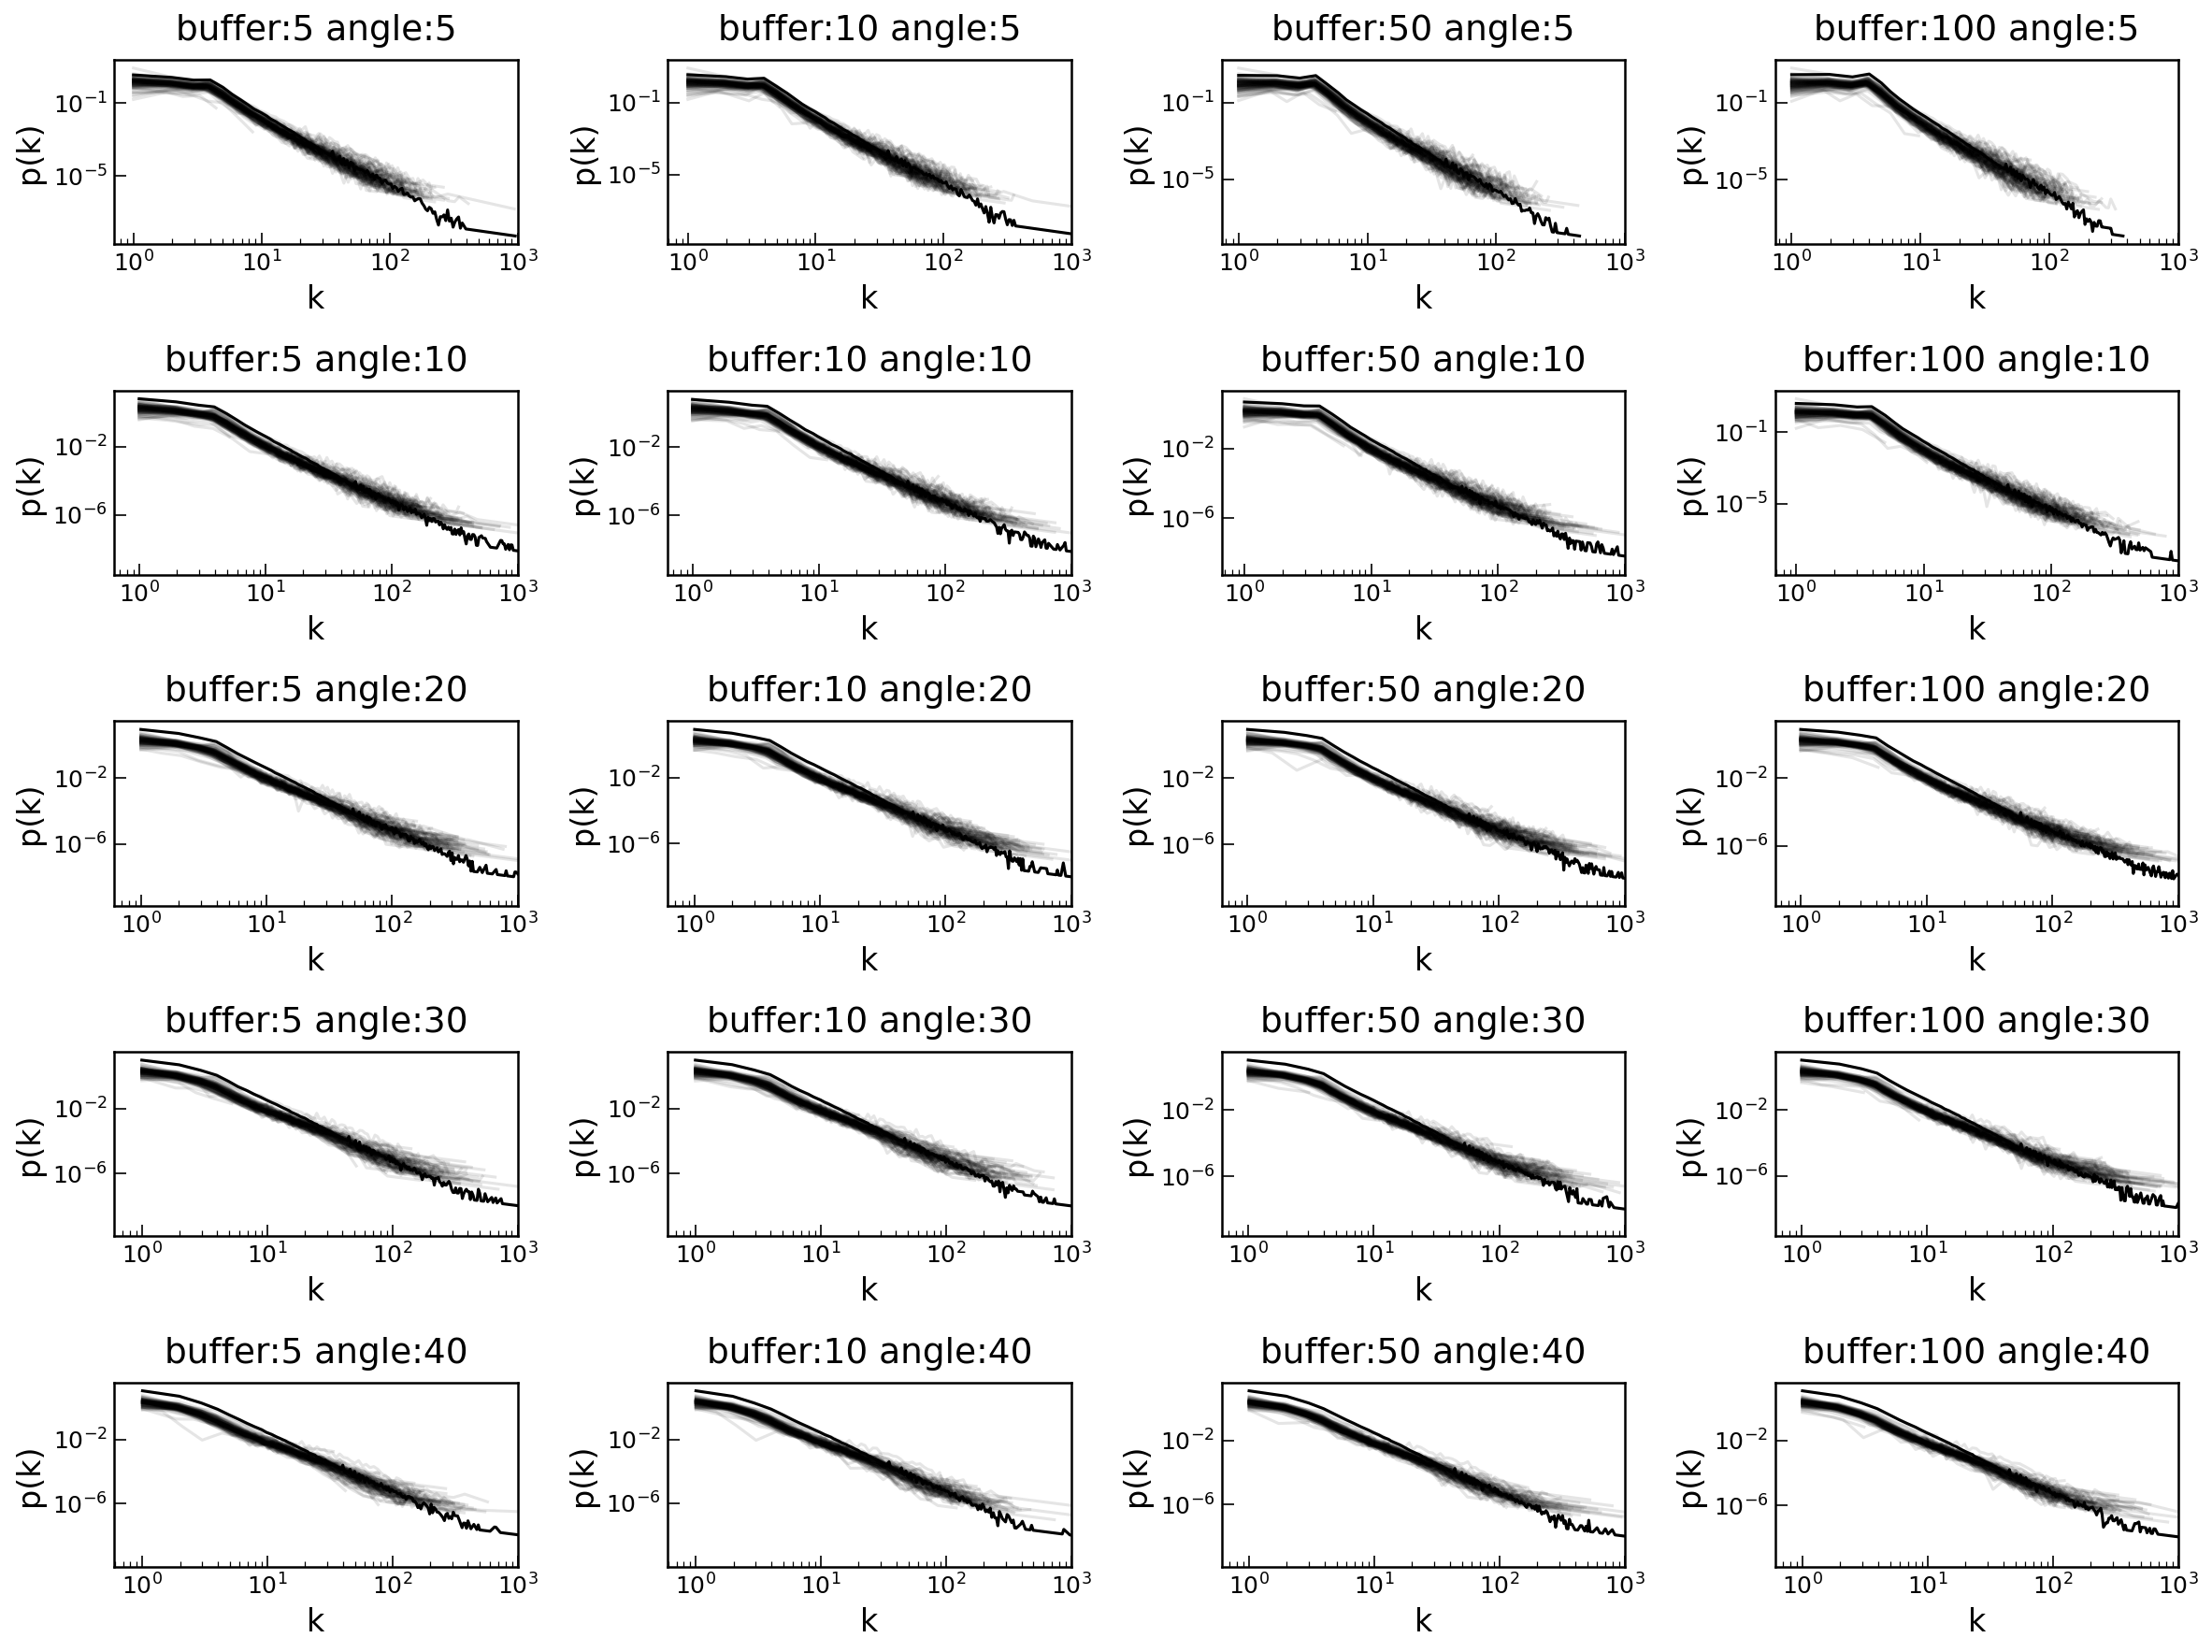

In [ ]:
t_s = [5, 10, 50, 100]
a_s = [5, 10, 20, 30, 40]

fig, axs = plt.subplots(ncols=4, nrows=5,figsize=(16,12))
for xi, t_buf in enumerate(t_s):
    for yi, a_thresh in enumerate(a_s):
        ax=axs[yi, xi]
        ax.set_title(f'buffer:{int(t_buf)} angle:{int(a_thresh)}')
        path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f't{int(t_buf)}_a{int(a_thresh)}'+'/'

        full = np.array([])    
        cities = os.listdir(path)
        for city in cities:
            d=np.load(path+city)
            d = d['degree']
            full=np.append(full, d)

            y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
            x = x[:-1]
            x_nn = x[y != 0][:-1]
            y_nn = y[y != 0][:-1]
            ax.plot(x_nn, y_nn, alpha=0.1, zorder=2, color='k')

        ax.set_xscale('log')
        ax.set_yscale('log')

        # ax.set_title("Degree Distribution", loc='left', pad=12)
        ax.set_xlabel("k")
        ax.set_ylabel("p(k)")

        y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True)
        x = x[:-1]
        x_nn = x[y != 0][:-1]
        y_nn = y[y != 0][:-1]
        ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='k')
        ax.yaxis.set_minor_formatter(plt.NullFormatter())  
        ax.set_xlim(right=1000)

plt.tight_layout()
plt.show()

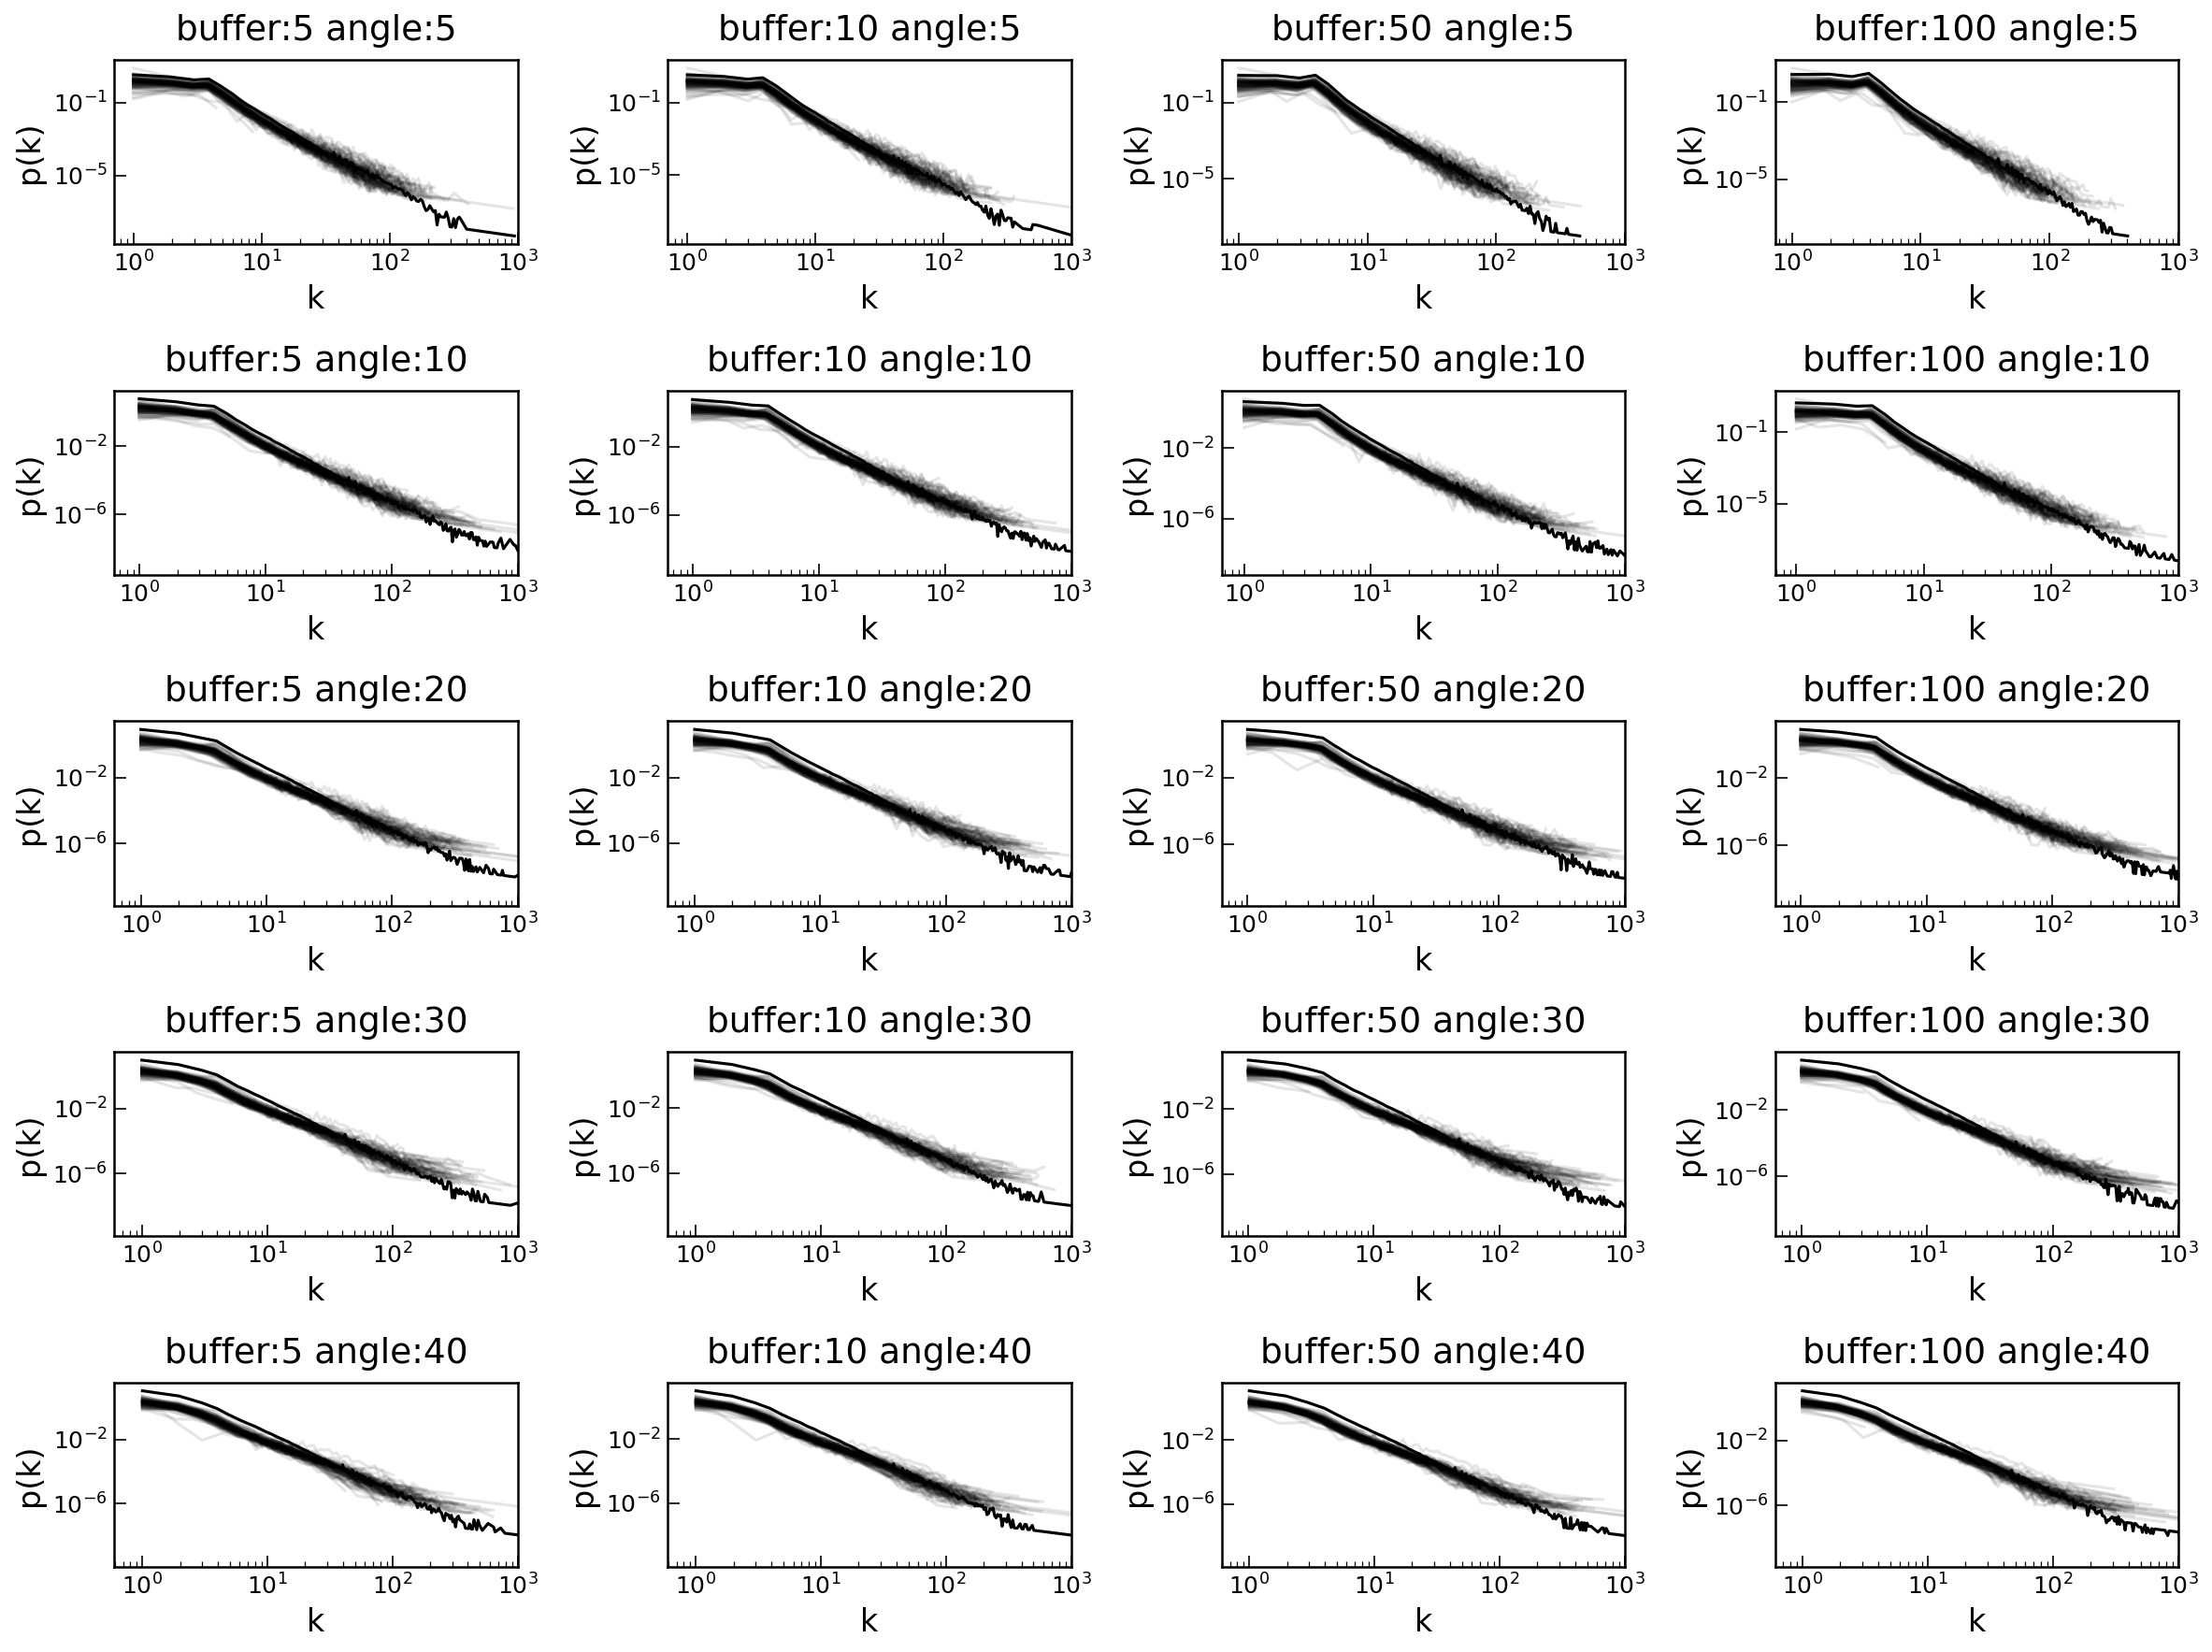

In [41]:
t_s = [5, 10, 50, 100]
a_s = [5, 10, 20, 30, 40]

fig, axs = plt.subplots(ncols=4, nrows=5,figsize=(16,12))
for xi, t_buf in enumerate(t_s):
    for yi, a_thresh in enumerate(a_s):
        ax=axs[yi, xi]
        ax.set_title(f'buffer:{int(t_buf)} angle:{int(a_thresh)}')
        path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f't{int(t_buf)}_a{int(a_thresh)}_no_simplify'+'/'

        full = np.array([])    
        cities = os.listdir(path)
        for city in cities:
            d=np.load(path+city)
            d = d['degree']
            full=np.append(full, d)

            y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
            x = x[:-1]
            x_nn = x[y != 0][:-1]
            y_nn = y[y != 0][:-1]
            ax.plot(x_nn, y_nn, alpha=0.1, zorder=2, color='k')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel("k")
        ax.set_ylabel("p(k)")

        y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True)
        x = x[:-1]
        x_nn = x[y != 0][:-1]
        y_nn = y[y != 0][:-1]
        ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='k')
        ax.yaxis.set_minor_formatter(plt.NullFormatter())  
        ax.set_xlim(right=1000)

plt.tight_layout()
plt.show()

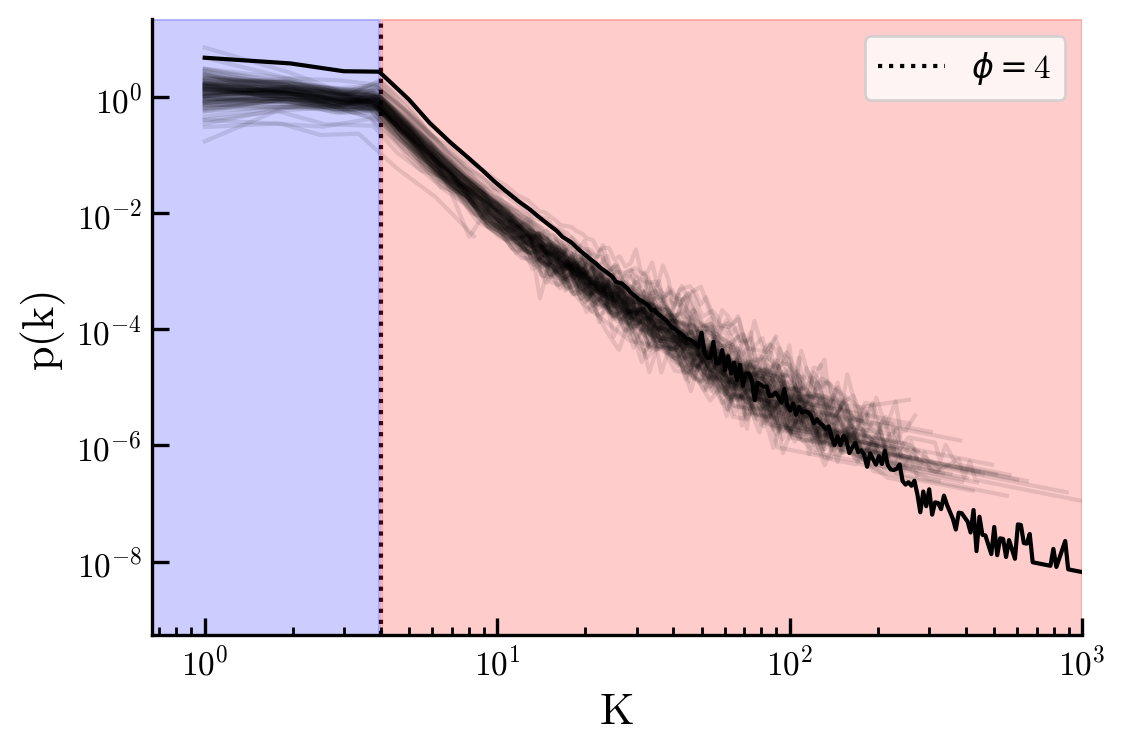

In [3]:
f = 't50_a10'
path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f+'/'
full = np.array([])
fig, ax = plt.subplots(figsize=(6, 4),dpi=200)

cities = os.listdir(path)
for city in cities:
    d=np.load(path+city)
    d = d['degree']
    full=np.append(full, d)

    y, x = np.histogram(d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True)
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax.plot(x_nn, y_nn, alpha=0.1, zorder=2, color='k')

ax.set_xscale('log')
ax.set_yscale('log')

# ax.set_title("Degree Distribution", loc='left', pad=12)
ax.set_xlabel("K")
ax.set_ylabel("p(k)")

y, x = np.histogram(full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, alpha=1, zorder=2, color='k')

ax.yaxis.set_minor_formatter(plt.NullFormatter())


# Hide top/right spines (Nature style)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Only bottom/left axes
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

# Major ticks (not too many)
ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))

# Minor ticks
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))

# Appearance
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)

# Shade area from "x = 0" (small positive) up to x = 7
ax.axvline(4, color='k', linestyle='dotted', label=r'$\phi = $' + str(4),zorder=-1)
ax.axvspan(xmin=0, xmax=3.95, color='blue', alpha=0.2, zorder=-1)
ax.axvspan(xmin=4.01, xmax=1000, color='red', alpha=0.2, zorder=-1)

plt.legend()
ax.set_xlim(right=1000)
plt.show()

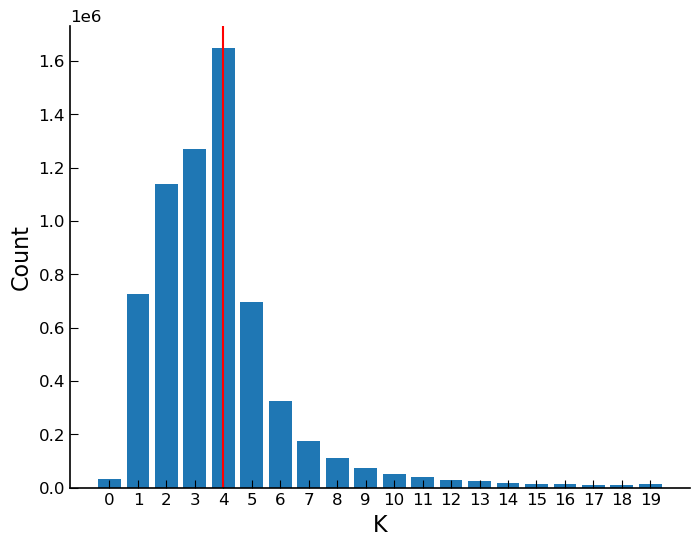

In [10]:
fig, ax = plt.subplots(figsize=(8,6),dpi=100)

N = 20
data = full[full <= N]
counts, bin_edges = np.histogram(data, bins=N)
bin_centers = np.arange(0,N)
plt.bar(bin_centers, counts)
plt.xlabel('K')
plt.ylabel('Count')
plt.axvline(4,color='red')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xticks(bin_centers)
plt.show()

In [21]:
d_max = []
for city in cities:
    d=np.load(path+city)
    d = d['degree']
    d_max.append(np.unique_counts(d)[1].argmax())

print(d_max)

[np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(3), np.int64(3), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(3), np.int64(4), np.int64(4), np.int64(4), np.int64(1), np.int64(4), np.int64(2), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(3), np.int64(3), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(2), np.int64(4), np.int64(4), np.int64(4), np.int64(4), np.int64(4)

In [5]:
def compute_ks(degree,min_range):
    distance = []
    ass = []
    for i_min in min_range:
        fit = powerlaw.Fit(degree,discrete=True,xmin=i_min)
        a = fit.alpha
        xmin = fit.xmin
        x_fit = degree[degree>xmin]
        
        distance.append(fit.power_law.D)
        ass.append(a) 

    return np.array(distance), min_range, ass

4it [01:49, 27.27s/it]


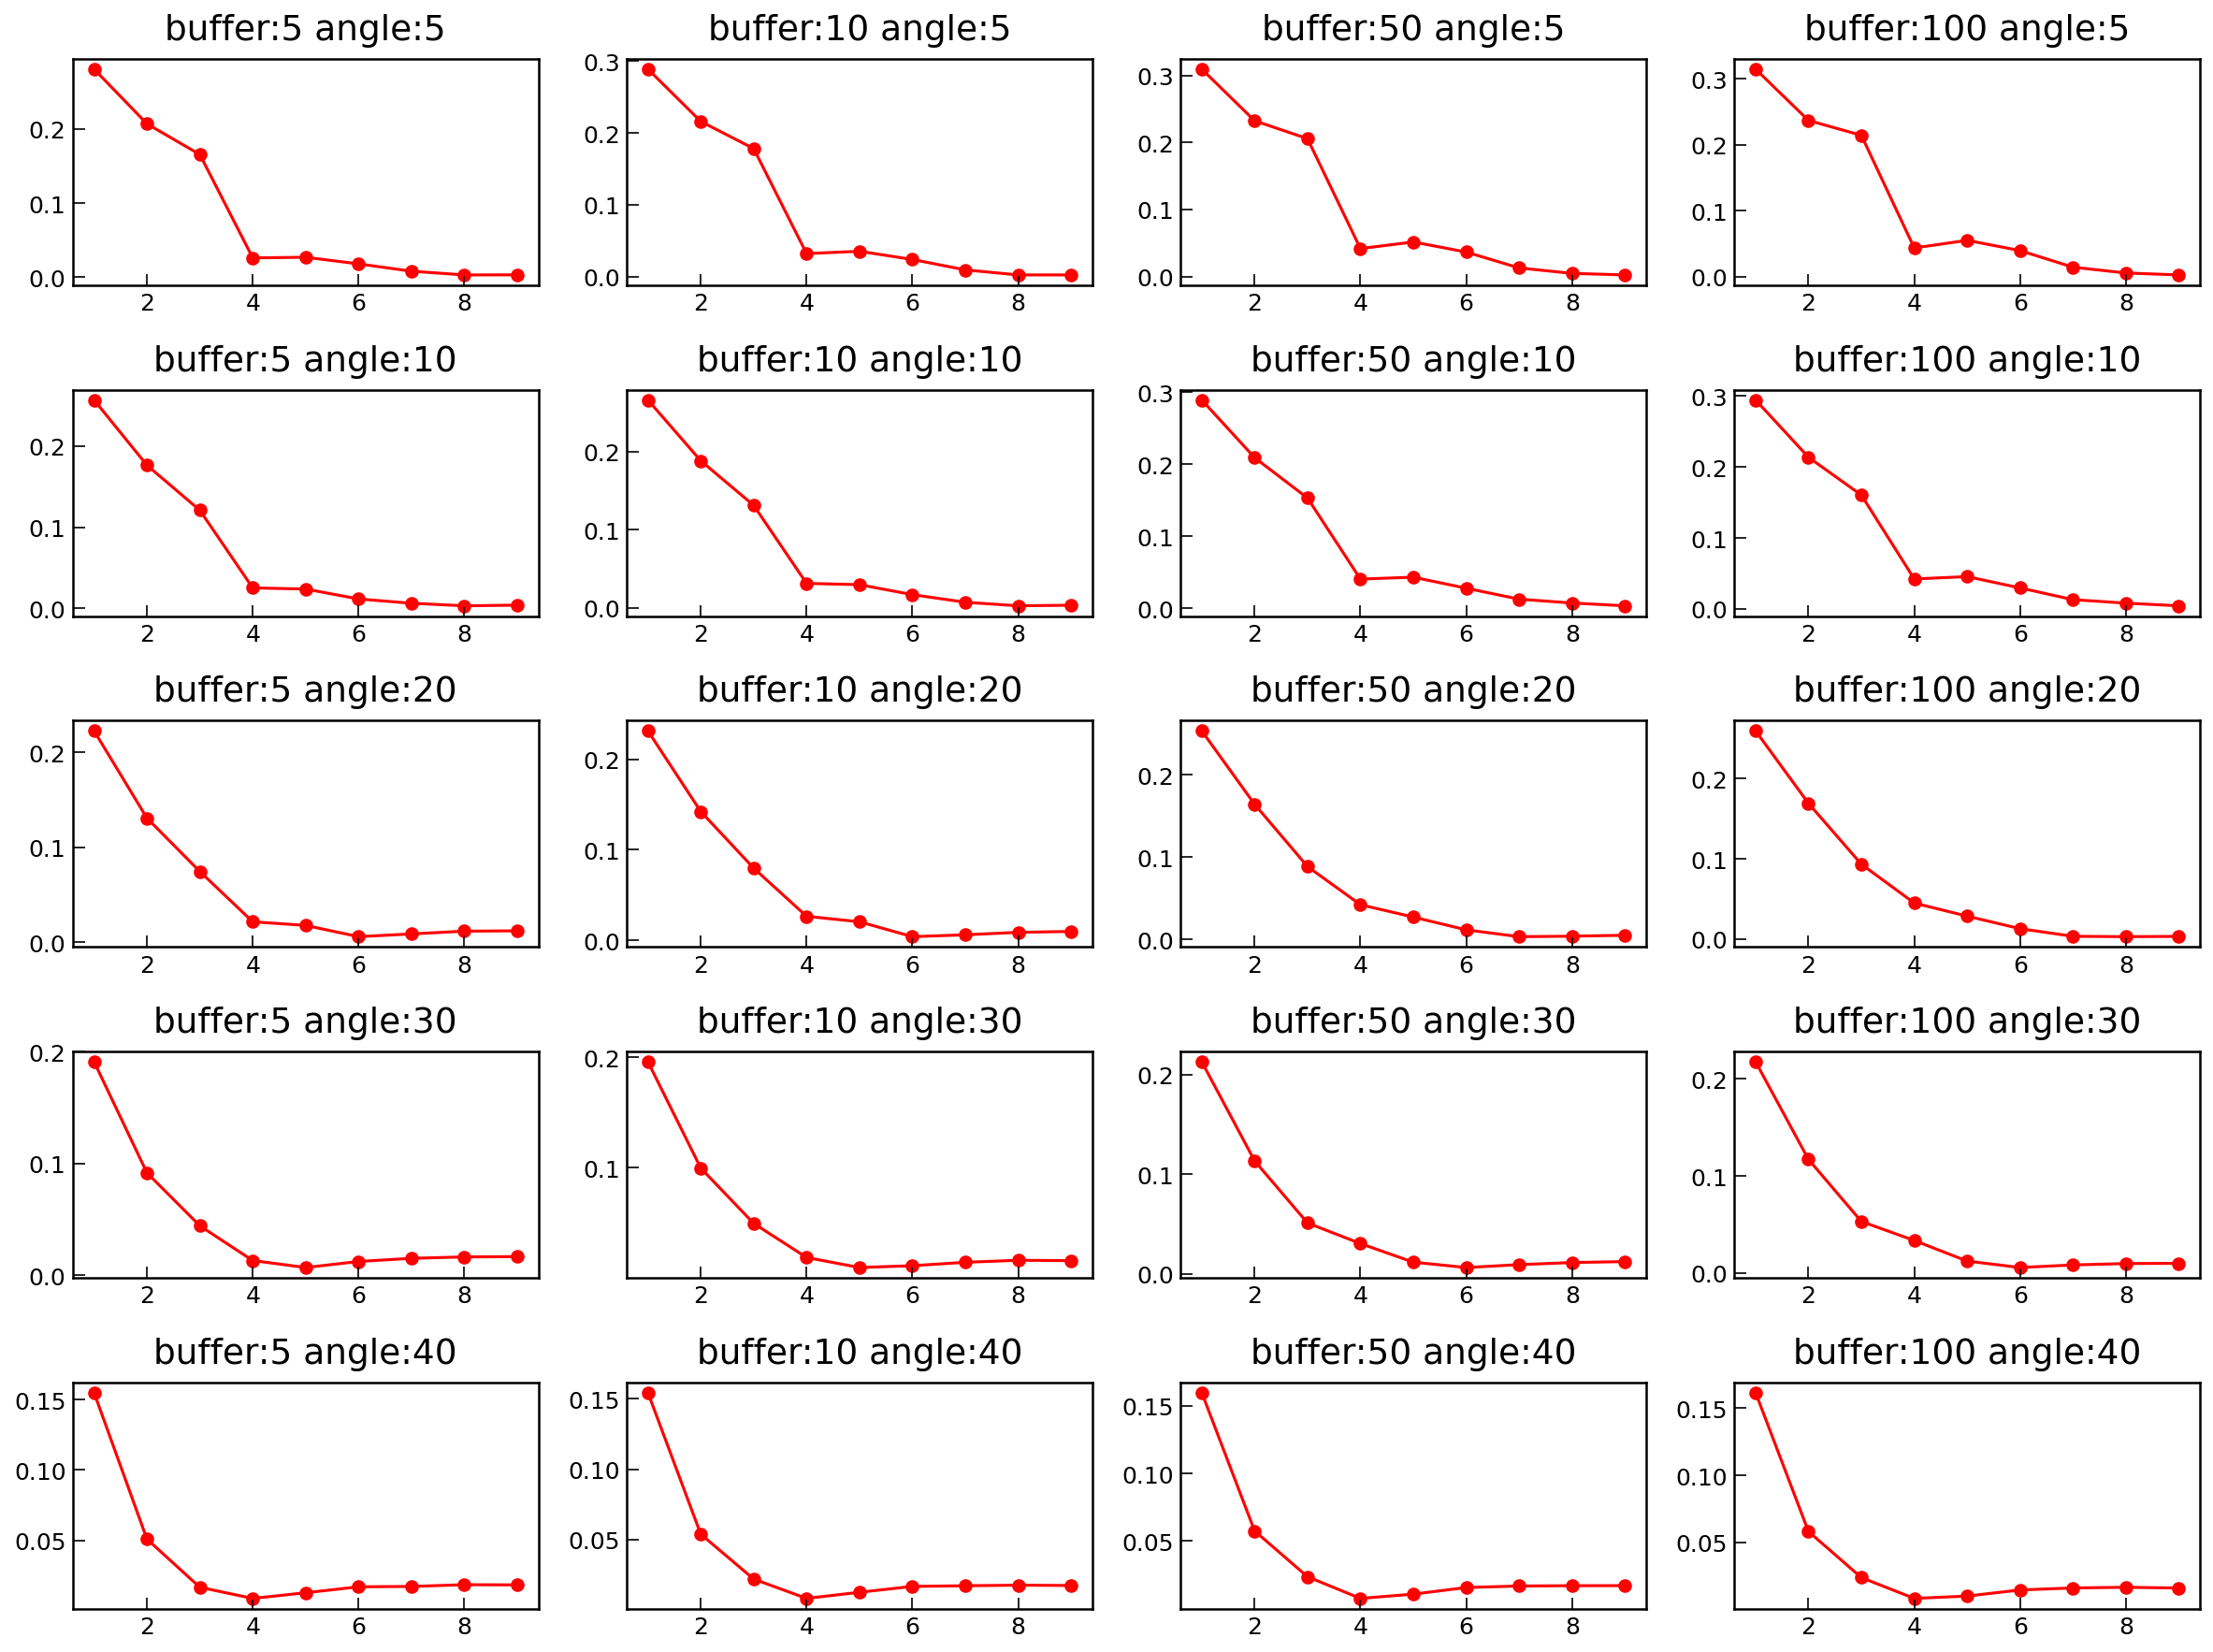

In [5]:
t_s = [5, 10, 50, 100]
a_s = [5, 10, 20, 30, 40]

fig, axs = plt.subplots(ncols=4, nrows=5,figsize=(16,12))
for xi, t_buf in tqdm(enumerate(t_s)):
    for yi, a_thresh in enumerate(a_s):
        ax=axs[yi, xi]
        ax.set_title(f'buffer:{int(t_buf)} angle:{int(a_thresh)}')
        
        path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f't{int(t_buf)}_a{int(a_thresh)}'+'/'
        full = np.array([])    
        cities = os.listdir(path)
        for city in cities:
            d=np.load(path+city)
            d = d['degree']
            full=np.append(full, d)

        full = full[full != 0]
        ks_dist, xmins, a = compute_ks(full, range(1,10))
        ax.scatter(xmins,ks_dist,color='red')
        ax.plot(xmins,ks_dist,color='red')

plt.tight_layout()
plt.show()

4it [02:29, 37.41s/it]


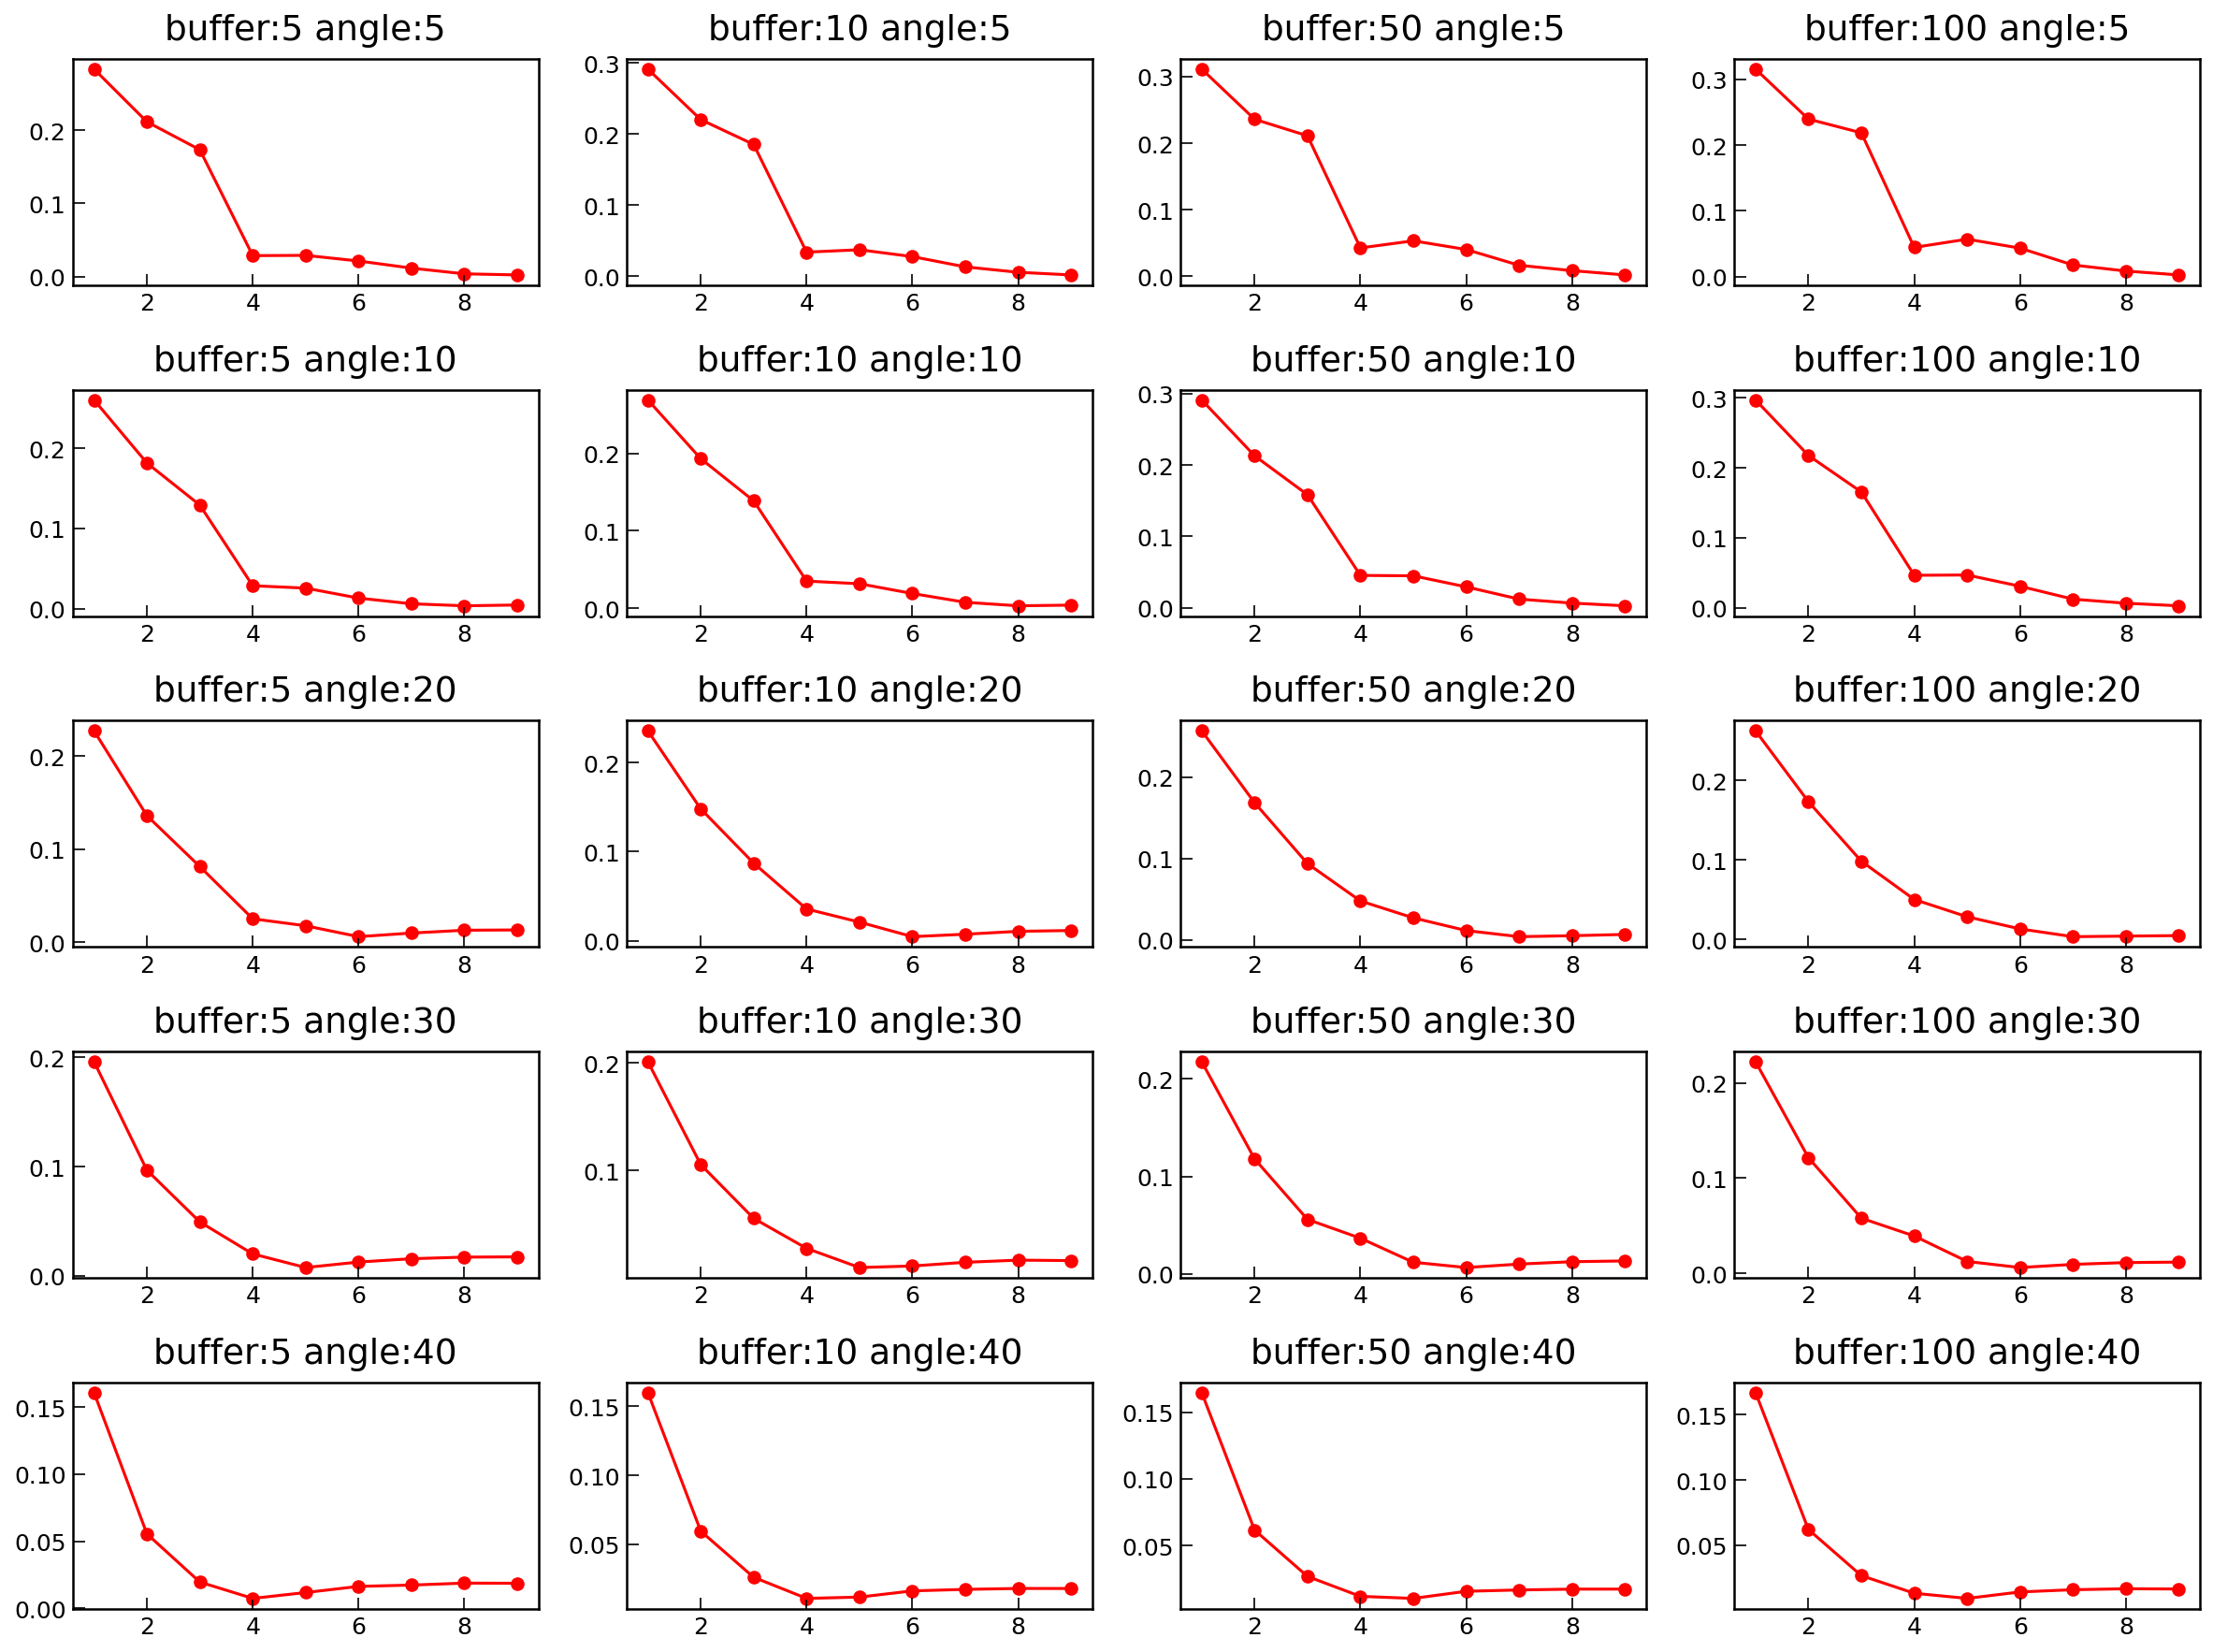

In [42]:
t_s = [5, 10, 50, 100]
a_s = [5, 10, 20, 30, 40]

fig, axs = plt.subplots(ncols=4, nrows=5,figsize=(16,12))
for xi, t_buf in tqdm(enumerate(t_s)):
    for yi, a_thresh in enumerate(a_s):
        ax=axs[yi, xi]
        ax.set_title(f'buffer:{int(t_buf)} angle:{int(a_thresh)}')
        
        path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f't{int(t_buf)}_a{int(a_thresh)}_no_simplify'+'/'
        full = np.array([])    
        cities = os.listdir(path)
        for city in cities:
            d=np.load(path+city)
            d = d['degree']
            full=np.append(full, d)

        full = full[full != 0]
        ks_dist, xmins, a = compute_ks(full, range(1,10))
        ax.scatter(xmins,ks_dist,color='red')
        ax.plot(xmins,ks_dist,color='red')

plt.tight_layout()
plt.show()

/tmp/ipykernel_349960/3784319188.py:26: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) cmr10.
  plt.tight_layout()
/home/lpsha/.conda/envs/umap-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


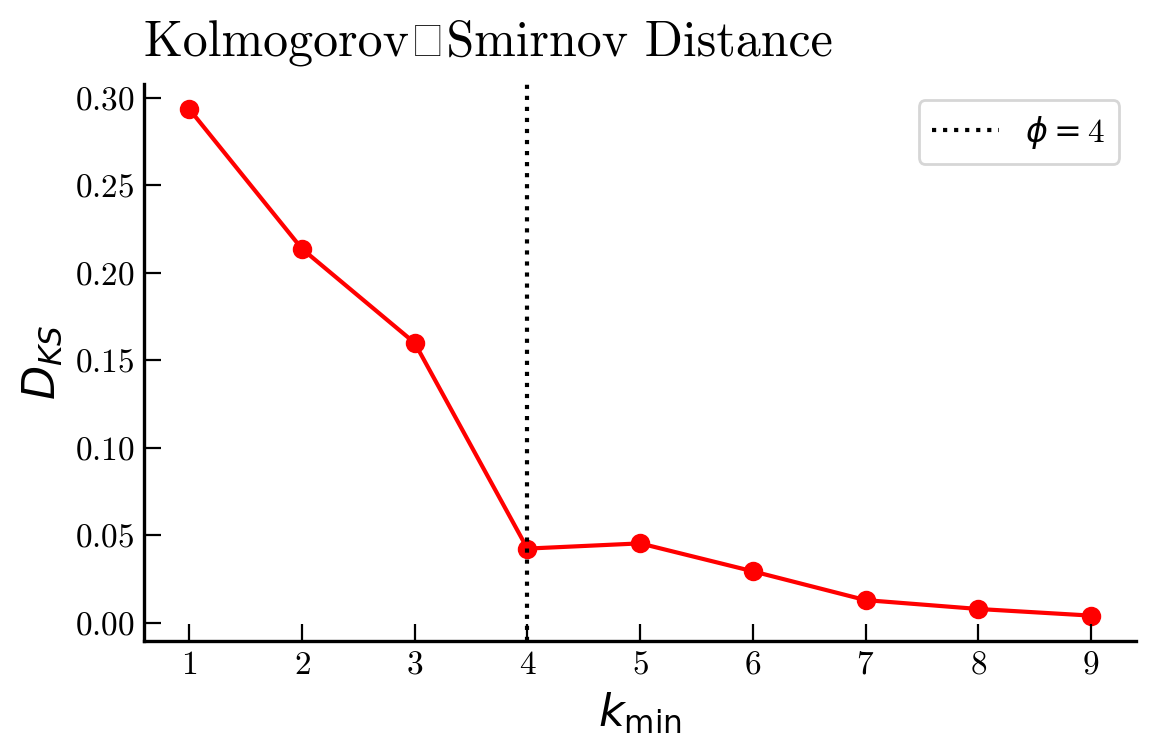

In [6]:
f = 't100_a10'
path = '/home/lpsha/s154446/fractality/data/city_degrees/'+f+'/'
full = np.array([])
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4),dpi=200)
cities = os.listdir(path)
# --- Degree Distribution ---
for city in cities:
    d = np.load(path+city)['degree']
    full = np.append(full, d)

# --- KS Distance ---
d = full[full != 0]
ks_dist, xmins, a = compute_ks(d, range(1, 10))
shift = 4
ax.scatter(xmins, ks_dist, color='red')
ax.plot(xmins, ks_dist, color='red')
ax.axvline(shift, color='k', linestyle='dotted', label=r'$\phi = $' + str(shift))
ax.set_xlabel(r'$k_{\min}$')
ax.set_ylabel(r'$D_{KS}$')
ax.set_title('Kolmogorov–Smirnov Distance', loc='left')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_349960/3229042764.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


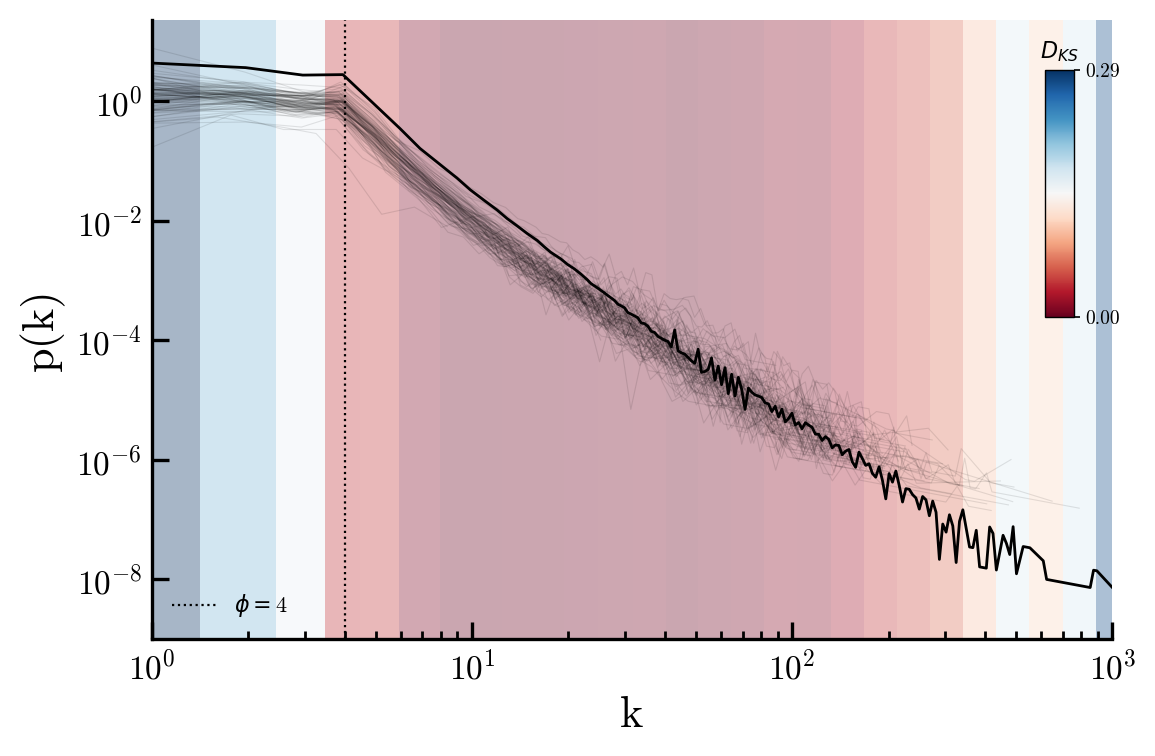

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

f = 't100_a10'
path = '/home/lpsha/s154446/fractality/data/city_degrees/' + f + '/'

full = np.array([])
cities = os.listdir(path)

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

# --- per-city distributions ---
for city in cities:
    d = np.load(path + city)['degree']
    full = np.append(full, d)

    y, x = np.histogram(
        d, bins=np.logspace(0, np.log10(d.max()), len(np.unique(d))), density=True
    )
    x = x[:-1]
    x_nn = x[y != 0][:-1]
    y_nn = y[y != 0][:-1]
    ax.plot(x_nn, y_nn, alpha=0.1, color='k', zorder=2, linewidth=0.4)

# --- KS distance on log-spaced xmins covering full plot range ---
d_full = full[full != 0]
xmins = np.unique(np.round(np.logspace(0, np.log10(1000), 30)).astype(int))
xmins = xmins[xmins < d_full.max()]
ks_dist, xmins_used, alphas = compute_ks(d_full, xmins)
ks_dist = np.asarray(ks_dist)
xmins_used = np.asarray(xmins_used, dtype=float)

# --- KS-colored background ---
ks_norm = (ks_dist - ks_dist.min()) / (ks_dist.max() - ks_dist.min())
cmap = plt.cm.RdBu          # low → red, high → blue

# bin edges between consecutive xmins (geometric midpoints, extended to plot limits)
edges = np.concatenate([[1.0],
                        np.sqrt(xmins_used[:-1] * xmins_used[1:]),
                        [1000.0]])

for i in range(len(ks_norm)):
    ax.axvspan(edges[i], edges[i + 1],
               color=cmap(ks_norm[i]), alpha=0.35,
               zorder=-1, linewidth=0)

# --- aggregate distribution ---
y, x = np.histogram(
    full, bins=np.logspace(0, np.log10(full.max()), len(np.unique(full))), density=True
)
x = x[:-1]
x_nn = x[y != 0][:-1]
y_nn = y[y != 0][:-1]
ax.plot(x_nn, y_nn, color='k', zorder=2, linewidth=1.0)

# --- phi line ---
shift = 4
ax.axvline(shift, color='k', linestyle='dotted',
           label=r'$\phi = $' + str(shift), zorder=3, linewidth=0.8)

# --- axes / styling ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('k')
ax.set_ylabel('p(k)')
ax.set_xlim(left=1, right=1000)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

ax.xaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.yaxis.set_major_locator(plt.LogLocator(base=10.0))
ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)))
ax.yaxis.set_minor_formatter(plt.NullFormatter())
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)

# --- colorbar (Nature/Science style: thin inset, minimal ticks) ---
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=plt.Normalize(ks_dist.min(), ks_dist.max())
)
sm.set_array([])

cax = inset_axes(
    ax,
    width="3%", height="40%",
    loc='upper right',
    bbox_to_anchor=(-0.04, -0.08, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
cbar = fig.colorbar(sm, cax=cax)

cbar.set_ticks([ks_dist.min(), ks_dist.max()])
cbar.set_ticklabels([f'{ks_dist.min():.2f}', f'{ks_dist.max():.2f}'])

cbar.outline.set_linewidth(0.5)
cax.tick_params(width=0.6, length=2, direction='out', labelsize=7, pad=2)
cax.set_title(r'$D_{KS}$', fontsize=8, pad=4)

ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()